<a href="https://colab.research.google.com/github/SpringBoard795/PicasoPhrase_Infosys_Internship_Nov2024/blob/MerajBegum/FeatureMapExtraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#VGG16 Feature Map Extraction


In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

In [ ]:
base_model=VGG16(weights='imagenet')

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
from tensorflow.keras.models import Model

In [ ]:
model=Model(inputs=base_model.input,outputs=base_model.get_layer("block5_conv3").output)

In [ ]:
def load_and_preprocess_image(image_path,target_size=(224,224)):
  img=image.load_img(r"/content/download.jpg",target_size=target_size)
  img_array=image.img_to_array(img)
  img_array=np.expand_dims(img_array,axis=0)
  img_array=preprocess_input(img_array)
  return img_array

In [ ]:
img=image.load_img(r"/content/download.jpg",target_size=(224,224))

In [ ]:
img.size

(224, 224)

In [ ]:
img_array=image.img_to_array(img)

In [ ]:
img_array

array([[[57., 47., 37.],
        [56., 46., 34.],
        [58., 48., 36.],
        ...,
        [48., 40., 29.],
        [53., 45., 34.],
        [50., 40., 30.]],

       [[56., 48., 37.],
        [49., 41., 30.],
        [59., 51., 40.],
        ...,
        [57., 47., 37.],
        [45., 37., 24.],
        [51., 39., 27.]],

       [[62., 54., 43.],
        [63., 55., 44.],
        [57., 49., 38.],
        ...,
        [57., 45., 33.],
        [54., 41., 32.],
        [54., 42., 30.]],

       ...,

       [[ 8.,  8.,  6.],
        [ 4.,  4.,  4.],
        [ 0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.]],

       [[15., 14., 12.],
        [12., 12., 10.],
        [12., 12., 10.],
        ...,
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.]],

       [[ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.]]

In [ ]:
import numpy as np
img_array=np.expand_dims(img_array,axis=0)

In [ ]:
img_array=preprocess_input(img_array)

In [ ]:
img_array

array([[[[-294.558, -303.337, -294.299],
         [-297.558, -304.337, -295.299],
         [-295.558, -302.337, -293.299],
         ...,
         [-302.558, -310.337, -303.299],
         [-297.558, -305.337, -298.299],
         [-301.558, -310.337, -301.299]],

        [[-294.558, -302.337, -295.299],
         [-301.558, -309.337, -302.299],
         [-291.558, -299.337, -292.299],
         ...,
         [-294.558, -303.337, -294.299],
         [-307.558, -313.337, -306.299],
         [-304.558, -311.337, -300.299]],

        [[-288.558, -296.337, -289.299],
         [-287.558, -295.337, -288.299],
         [-293.558, -301.337, -294.299],
         ...,
         [-298.558, -305.337, -294.299],
         [-299.558, -309.337, -297.299],
         [-301.558, -308.337, -297.299]],

        ...,

        [[-325.558, -342.337, -343.299],
         [-327.558, -346.337, -347.299],
         [-331.558, -350.337, -351.299],
         ...,
         [-331.558, -350.337, -351.299],
         [-331.558, -3

In [ ]:
feature_map=model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 41s 41s/step


In [ ]:
n_features=feature_map.shape[-1]

In [ ]:
n_features

512

In [ ]:
size=feature_map.shape[1]

In [ ]:
from PIL import Image

In [ ]:
img=Image.open("/content/download.jpg")

In [ ]:
img.size

(2970, 3713)

In [ ]:
display_grid=np.zeros((size,size*n_features))

In [ ]:
display_grid

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
for i in range(n_features):
  x=feature_map[0,:,:,i]
  x-=x.mean()
  x/=(x.std()+1e-5)
  x*=64
  x+=128
  x=np.clip(x,0,255).astype(int)
  display_grid[:,i*size:(i+1)*size]=x

In [ ]:
scale=20./n_features

In [ ]:
import matplotlib.pyplot as plt

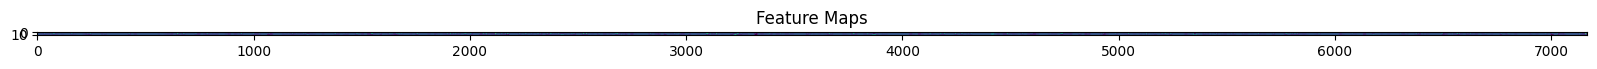

In [ ]:
plt.figure(figsize=(scale*n_features,scale))
plt.title("Feature Maps")
plt.grid(False)
plt.imshow(display_grid,aspect="auto")

In [ ]:
import tensorflow as tf

In [ ]:
base_model=tf.keras.applications.ResNet50(weights="imagenet",include_top=False)
base_model.trainable=False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
img=tf.keras.preprocessing.image.load_img("/content/download.jpg",target_size=(224,224))

In [ ]:
img_array=tf.keras.preprocessing.image.img_to_array(img)
img_array=np.expand_dims(img_array,axis=0)

In [ ]:
img_array.shape

(1, 224, 224, 3)

In [ ]:
img_array=tf.keras.applications.resnet.preprocess_input(img_array)

In [ ]:
img_array.shape

(1, 224, 224, 3)

In [ ]:
img_array

array([[[[ -66.939   ,  -69.779   ,  -66.68    ],
         [ -69.939   ,  -70.779   ,  -67.68    ],
         [ -67.939   ,  -68.779   ,  -65.68    ],
         ...,
         [ -74.939   ,  -76.779   ,  -75.68    ],
         [ -69.939   ,  -71.779   ,  -70.68    ],
         [ -73.939   ,  -76.779   ,  -73.68    ]],

        [[ -66.939   ,  -68.779   ,  -67.68    ],
         [ -73.939   ,  -75.779   ,  -74.68    ],
         [ -63.939003,  -65.779   ,  -64.68    ],
         ...,
         [ -66.939   ,  -69.779   ,  -66.68    ],
         [ -79.939   ,  -79.779   ,  -78.68    ],
         [ -76.939   ,  -77.779   ,  -72.68    ]],

        [[ -60.939003,  -62.779   ,  -61.68    ],
         [ -59.939003,  -61.779   ,  -60.68    ],
         [ -65.939   ,  -67.779   ,  -66.68    ],
         ...,
         [ -70.939   ,  -71.779   ,  -66.68    ],
         [ -71.939   ,  -75.779   ,  -69.68    ],
         [ -73.939   ,  -74.779   ,  -69.68    ]],

        ...,

        [[ -97.939   , -108.779   , -1

In [ ]:
feature_map=base_model(img_array)

In [ ]:
feature_map.shape

TensorShape([1, 7, 7, 2048])

# ANN

In [ ]:
import pandas as pd

In [ ]:
data={
    "Title": [
        "Breaking news: COVID-19 vaccine is a scam!",
        "NASA discovers new planet with signs of life",
        "Fake celebrity dies in car crash story circulates",
        "New study confirms coffee boosts productivity"
    ],
    "Label": [1, 0, 1, 0]  # 1 = Fake, 0 = Real
}

In [ ]:
df=pd.DataFrame(data)

In [ ]:
df

,Title,Label
0,Breaking news: COVID-19 vaccine is a scam!,1
1,NASA discovers new planet with signs of life,0
2,Fake celebrity dies in car crash story circulates,1
3,New study confirms coffee boosts productivity,0


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf=TfidfVectorizer(max_features=50)

In [ ]:
X=tfidf.fit_transform(df['Title']).toarray()
y=df['Label']

In [ ]:
X

array([[0.37796447, 0.        , 0.37796447, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.37796447, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.37796447,
        0.        , 0.        , 0.        , 0.37796447, 0.        ,
        0.        , 0.        , 0.37796447, 0.        , 0.        ,
        0.        , 0.37796447, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.36222393, 0.        , 0.        , 0.        ,
        0.36222393, 0.36222393, 0.2855815 , 0.        , 0.36222393,
        0.36222393, 0.        , 0.        , 0.36222393, 0.        ,
        0.        , 0.        , 0.36222393],
       [0.        , 0.        , 0.        , 0.35355339, 0.35355339,
        0.35355339, 0.        , 0.        , 0.        , 0.35355339,
        0.35355339, 0.        , 0.35355339, 0.35355339, 0.        ,
        0.        , 0.    

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

In [ ]:
model=Sequential([
                Dense(64,activation="relu",input_shape=(X.shape[1],)),
                Dropout(0.5),
                Dense(32,activation="relu"),
                Dense(1,activation="sigmoid")

])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001),loss=BinaryCrossentropy(),metrics=['accuracy'])

In [ ]:
model.fit(X,y,epochs=10)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.5000 - loss: 0.6845
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7500 - loss: 0.6662
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.7500 - loss: 0.6115
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.7500 - loss: 0.6548
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.5000 - loss: 0.6518
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.5000 - loss: 0.6991
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.7500 - loss: 0.5907
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 1.0000 - loss: 0.5677
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 1.0000 - loss: 0.6182
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.5000 - loss: 0.6372


In [ ]:
loss,accuracy=model.evaluate(X,y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.7500 - loss: 0.5915


In [ ]:
loss,accuracy

(0.5914837718009949, 0.75)

In [ ]:
model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


array([[0.4983699 ],
       [0.43439165],
       [0.5654583 ],
       [0.41113025]], dtype=float32)

In [ ]:
y

,Label
0,1
1,0
2,1
3,0


#RNN

In [ ]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 32.7 MB/s eta 0:00:00


In [ ]:
from faker import Faker

In [ ]:
import numpy as np

In [ ]:
fake=Faker()
Faker.seed(42)

In [ ]:
def generate_text_labels(num_samples=5000):
  text=[fake.sentence(nb_words=10) for i in range(num_samples)]
  labels=np.random.randint(0,2,num_samples)
  return text,labels

In [ ]:
text,labels=generate_text_labels()

In [ ]:
text

['Agent every development say quality throughout beautiful.',
 'All behavior discussion own night respond red information last everything thank.',
 'Recently future choice whatever from behavior benefit suggest.',
 'Enough analysis least by two bad fall pick those gun court attorney product.',
 'World talk term herself law street class great prove.',
 'Participant commercial rock clear here writer.',
 'Detail food shoulder argue start source husband at tree note responsibility defense material.',
 'Central cause seat much section investment on gun young catch management.',
 'Technology check civil quite others his.',
 'You more wife team activity result race Mr environment political born itself law.',
 'Will seven medical blood personal success medical current hear.',
 'Much single morning a food affect upon these.',
 'Dream drive note bad rule staff within mouth call.',
 'Water close month parent who up sense ready require human public health.',
 'Later easy ask again network open acc

In [ ]:
labels

array([0, 1, 0, ..., 0, 0, 0])

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [ ]:
tokenizer=Tokenizer(num_words=5000)

In [ ]:
tokenizer.fit_on_texts(text)

In [ ]:
sequences=tokenizer.texts_to_sequences(text)

In [ ]:
sequences

[[738, 228, 739, 821, 378, 191, 650],
 [330, 29, 379, 487, 192, 782, 229, 740, 282, 42, 822],
 [230, 30, 331, 117, 741, 29, 231, 22],
 [651, 91, 283, 590, 284, 118, 285, 652, 119, 120, 783, 784, 332],
 [424, 193, 23, 425, 16, 43, 785, 426, 742],
 [333, 956, 286, 121, 334, 743],
 [957, 696, 92, 335, 653, 75, 122, 427, 428, 76, 591, 232, 194],
 [592, 233, 915, 697, 336, 593, 698, 120, 429, 123, 699],
 [744, 870, 700, 195, 337, 338],
 [5, 60, 44, 594, 339, 234, 488, 287, 288, 31, 654, 289, 16],
 [538, 430, 340, 61, 290, 235, 340, 952, 786],
 [697, 45, 964, 431, 696, 871, 936, 432],
 [380, 291, 76, 118, 823, 787, 152, 539, 341],
 [46, 655, 489, 32, 656, 196, 24, 197, 342, 788, 153, 236],
 [490, 491, 492, 62, 595, 824, 343, 745, 237, 2, 330, 596],
 [540, 292, 238, 433, 825, 124, 344, 541, 542, 77, 434, 381],
 [154, 78, 8, 701, 493, 382, 286, 345, 597, 783, 890],
 [33, 42, 63, 746, 383, 744, 93],
 [543, 155, 916, 29, 747, 702],
 [494, 657, 122, 198, 598, 424, 435, 541, 293, 294, 117],
 [332,

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_sequences=pad_sequences(sequences,maxlen=20)

In [ ]:
padded_sequences[:2]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        738, 228, 739, 821, 378, 191, 650],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 330,  29, 379, 487,
        192, 782, 229, 740, 282,  42, 822]], dtype=int32)

In [ ]:
train_size=int(0.8*len(padded_sequences))

In [ ]:
train_size

4000

In [ ]:
X_train,X_test=padded_sequences[:train_size],padded_sequences[train_size:]
y_train,y_test=labels[:train_size],labels[train_size:]

In [ ]:
X_train

array([[  0,   0,   0, ..., 378, 191, 650],
       [  0,   0,   0, ..., 282,  42, 822],
       [  0,   0,   0, ...,  29, 231,  22],
       ...,
       [  0,   0,   0, ..., 220, 935, 730],
       [  0,   0,   0, ..., 734, 649, 361],
       [  0,   0,   0, ...,   6,  63, 515]], dtype=int32)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense

In [ ]:
model=Sequential([Embedding(input_dim=5000,output_dim=64,input_length=20),
                  SimpleRNN(64,return_sequences=False),
                  Dense(1,activation="sigmoid")
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=['accuracy'])

In [ ]:
model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5237 - loss: 0.6960 - val_accuracy: 0.5038 - val_loss: 0.6967
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7678 - loss: 0.5707 - val_accuracy: 0.5050 - val_loss: 0.7976
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9275 - loss: 0.2491 - val_accuracy: 0.4750 - val_loss: 1.2085
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9836 - loss: 0.0914 - val_accuracy: 0.4825 - val_loss: 1.7167
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9983 - loss: 0.0214 - val_accuracy: 0.4975 - val_loss: 2.1021
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9998 - loss: 0.0067 - val_accuracy: 0.4775 - val_loss: 2.3403
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.4837 - val_loss: 2.4726
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy:

In [ ]:
model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step


array([[1.28603324e-01],
       [4.95987944e-02],
       [2.20126030e-03],
       [9.99536276e-01],
       [8.20012748e-01],
       [9.99928951e-01],
       [3.54648125e-03],
       [9.78177667e-01],
       [8.70924115e-01],
       [6.17484562e-04],
       [9.99989152e-01],
       [2.28244498e-01],
       [3.23467970e-01],
       [9.96790409e-01],
       [3.14863923e-04],
       [9.14598405e-02],
       [9.99611557e-01],
       [9.99735773e-01],
       [9.99827385e-01],
       [9.99844909e-01],
       [9.99978602e-01],
       [1.62190627e-04],
       [3.91116971e-03],
       [9.96049285e-01],
       [2.87958868e-02],
       [2.63869017e-01],
       [9.84768927e-01],
       [9.99020338e-01],
       [9.99905884e-01],
       [4.26088691e-01],
       [9.99955237e-01],
       [1.43096428e-02],
       [9.98130083e-01],
       [5.14527202e-01],
       [9.05881166e-01],
       [9.93529379e-01],
       [9.96461213e-01],
       [3.19800436e-01],
       [1.13668837e-01],
       [9.98262107e-01],
